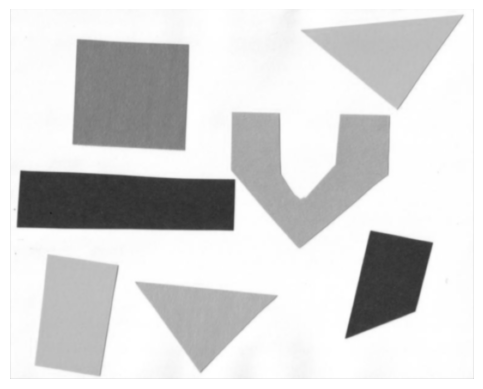

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_ames = cv2.imread('data/ames1.jpg')
img_ames = cv2.cvtColor(img_ames, cv2.COLOR_BGR2RGB)

plt.imshow(img_ames)
plt.axis('off')
plt.show()

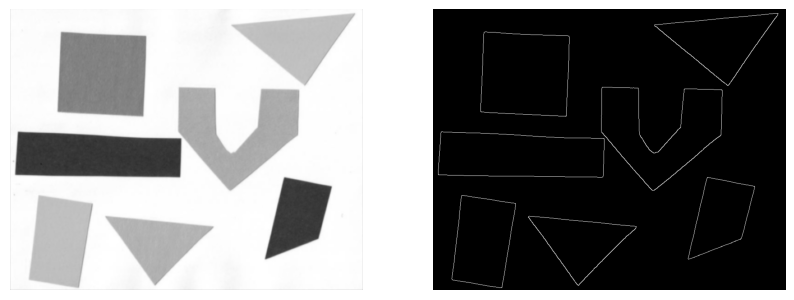

In [2]:
edges_ames = cv2.Canny(img_ames, 100, 200)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_ames)
axes[0].axis('off')

axes[1].imshow(edges_ames, cmap='gray')
axes[1].axis('off')

plt.show()

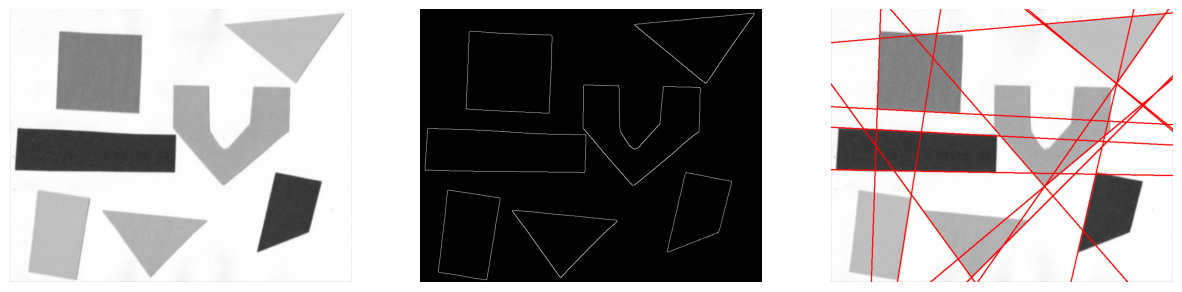

In [3]:
lines = cv2.HoughLines(edges_ames, 1, np.pi / 180, 130)
img_hough = img_ames.copy()

if lines is not None:
    for rho, theta in lines[:, 0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(img_hough, (x1, y1), (x2, y2), (255, 0, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_ames)
axes[0].axis('off')

axes[1].imshow(edges_ames, cmap='gray')
axes[1].axis('off')

axes[2].imshow(img_hough)
axes[2].axis('off')

plt.show()

E:\Miniconda\envs\opencv\lib\site-packages\matplotlib\animation.py:884: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


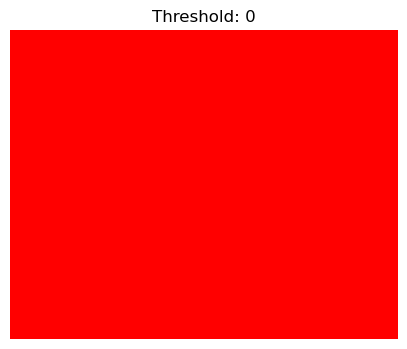

In [6]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(5, 5))
img_display = ax.imshow(img_ames.copy())
ax.axis('off')

def update(thresh):
    img_temp = img_ames.copy()
    lines = cv2.HoughLines(edges_ames, 1, np.pi / 180, thresh)
    if lines is not None:
        for rho, theta in lines[:, 0]:
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            cv2.line(img_temp, (x1, y1), (x2, y2), (255, 0, 0), 2)
    img_display.set_data(img_temp)
    ax.set_title(f"Threshold: {thresh}")

ani = FuncAnimation(fig, update, frames=range(0, 250, 5), interval=100)
HTML(ani.to_jshtml())